<a href="https://colab.research.google.com/github/amalo8/ProyectoNLP/blob/main/objetivo2_con_fechas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ahora introducimos las fechas


### Primera parte

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")



# ──────────────────────────────────────────────────────────────────────────────
# FASE 1: CARGA
# ──────────────────────────────────────────────────────────────────────────────
print("⏳ Cargando datos...")
df_info        = pd.read_csv('df_hoteles_vlc_info.csv')
df_comentarios = pd.read_csv('df_comentarios_final_topics.csv')

# ──────────────────────────────────────────────────────────────────────────────
# FASE 2: FEATURE ENGINEERING A NIVEL DE RESEÑA
# ──────────────────────────────────────────────────────────────────────────────
print("🧠 Construyendo features por reseña...")

df_comentarios['fecha'] = pd.to_datetime(df_comentarios['fecha'], dayfirst=False, errors='coerce')
df_comentarios = df_comentarios.dropna(subset=['fecha', 'nota'])

HALF_LIFE_DIAS = 180
fecha_ref = df_comentarios['fecha'].max()
df_comentarios['dias_antiguedad'] = (fecha_ref - df_comentarios['fecha']).dt.days
df_comentarios['peso_temporal']   = np.power(2, -df_comentarios['dias_antiguedad'] / HALF_LIFE_DIAS)

⏳ Cargando datos...
🧠 Construyendo features por reseña...


In [12]:
display(df_comentarios.head())

,nombre_del_hotel,nacionalidad,detalles_hab,noches,personas,comentario_general,positivo,negativo,nota,fecha,...,general_tokenizado_sinstop,positivo_tokenizado_sinstop,negativo_tokenizado_sinstop,general_lematizado_sinstop,positivo_lematizado_sinstop,negativo_lematizado_sinstop,tema_positivo,tema_negativo,dias_antiguedad,peso_temporal
0,barceló valencia,colombia,NaN,2,familia,espectacular,espectacular todo! restaurante; servicio; habi...,todo me gustó,10.0,2026-04-14,...,espectacular,espectacular restaurante servicio habitación t...,gustó,espectacular,espectacular restaurante servicio habitación t...,gustar,Limpieza - Confort - Personal - Instalaciones ...,Otro Tema / Mixto / Vacío,2,0.992328
1,barceló valencia,españa,NaN,1,pareja,muy bien,NaN,NaN,9.0,2026-04-05,...,NaN,NaN,NaN,NaN,NaN,NaN,Otro Tema / Mixto / Vacío,Otro Tema / Mixto / Vacío,11,0.958526
2,barceló valencia,españa,2 habitaciones dobles deluxe comunicadas,1,familia,fantástico,"habitaciones amplias, limpieza y ubicación",NaN,9.0,2026-04-03,...,fantástico,habitaciones amplias limpieza ubicación,NaN,fantástico,habitación amplio limpieza ubicación,NaN,Limpieza - Confort - Personal - Instalaciones ...,Otro Tema / Mixto / Vacío,13,0.951172
3,barceló valencia,españa,NaN,1,pareja,todo perfecto,el trato en recepción,el estacionamiento,10.0,2026-03-21,...,perfecto,trato recepción,estacionamiento,perfecto,trato recepción,estacionamiento,Personal - Instalaciones y Servicios,Instalaciones y Servicios - Ubicación,26,0.904728
4,barceló valencia,españa,NaN,2,pareja,una nit del foc inolvidable.,las vistas y el tamaño de la habitación.,"la calefacción central, sólo eso.",10.0,2026-03-20,...,nit foc inolvidable,vistas tamaño habitación,calefacción central,nit foc inolvidable,vista tamaño habitación,calefacción central,Confort - Instalaciones y Servicios,Limpieza - Confort,27,0.901250


In [13]:
# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [14]:
print("🧠 Calculando índices de sentimiento ponderados por tópico...")

categorias = ['Personal', 'Confort', 'WiFi', 'Instalaciones', 'Calidad/Precio', 'Limpieza', 'Ubicación']

# 1. Calculamos los índices base y sus valores ponderados
for cat in categorias:
    df_comentarios[f'{cat}_pos'] = df_comentarios['tema_positivo'].str.contains(cat, na=False, case=False).astype(int)
    df_comentarios[f'{cat}_neg'] = df_comentarios['tema_negativo'].str.contains(cat, na=False, case=False).astype(int)

    # Índice Neto de la reseña: (Positivo - Negativo). Rango de -1 a 1.
    df_comentarios[f'indice_{cat}'] = df_comentarios[f'{cat}_pos'] - df_comentarios[f'{cat}_neg']

    # NUEVO: Multiplicamos el índice por el peso temporal de esa reseña
    df_comentarios[f'indice_pond_{cat}'] = df_comentarios[f'indice_{cat}'] * df_comentarios['peso_temporal']

# 2. Agrupamos por hotel calculando la SUMA de los índices ponderados y de los pesos
cols_ponderadas = [f'indice_pond_{cat}' for cat in categorias]

# Sumamos tanto los productos (índice * peso) como la columna 'peso_temporal' por cada hotel
df_agrupado = df_comentarios.groupby('nombre_del_hotel')[cols_ponderadas + ['peso_temporal']].sum().reset_index()

# 3. Calculamos la media ponderada final (Suma del índice ponderado / Suma de los pesos)
for cat in categorias:
    df_agrupado[f'indice_{cat}'] = df_agrupado[f'indice_pond_{cat}'] / df_agrupado['peso_temporal']

# 4. Limpiamos el DataFrame final para dejar solo el nombre del hotel y los índices limpios
cols_finales = ['nombre_del_hotel'] + [f'indice_{cat}' for cat in categorias]
df_agrupado = df_agrupado[cols_finales]

display(df_agrupado.head())

🧠 Calculando índices de sentimiento ponderados por tópico...


,nombre_del_hotel,indice_Personal,indice_Confort,indice_WiFi,indice_Instalaciones,indice_Calidad/Precio,indice_Limpieza,indice_Ubicación
0,barceló valencia,0.212399,0.195120,0.004557,0.288567,0.000722,0.072284,0.203471
1,casual del cine valencia by casual hoteles,0.347369,0.146773,0.003949,0.350529,0.007655,0.095553,0.350113
2,casual vintage valencia,0.332452,0.175349,0.000585,0.397888,0.002081,0.079907,0.360100
3,hotel las arenas balneario resort,0.254325,0.184736,0.000944,0.314405,0.001854,0.089762,0.234475
4,ilunion aqua 3,0.148584,0.036199,0.001244,0.239374,-0.001292,0.002017,0.258458


In [15]:
# ------------------------------------------------------------------------------
# FASE 3: MERGE CON LAS NOTAS REALES DE BOOKING
# ------------------------------------------------------------------------------
print("🔗 Cruzando métricas NLP con notas reales de Booking...")

# Truco para evitar fallos por mayúsculas/minúsculas
df_agrupado['nombre_del_hotel_lower'] = df_agrupado['nombre_del_hotel'].str.lower()
df_info['nombre_del_hotel_lower'] = df_info['nombre_del_hotel'].str.lower()

# Unimos los datasets
df_final = pd.merge(
    df_info[['nombre_del_hotel_lower', 'nota_media_resenas', 'nombre_del_hotel']],
    df_agrupado,
    on='nombre_del_hotel_lower',
    how='inner'
)

# Limpiamos posibles nulos antes de entrenar
df_final = df_final.dropna(subset=['nota_media_resenas'] + cols_indices)

🔗 Cruzando métricas NLP con notas reales de Booking...


🤖 Entrenando el modelo de predicción (Random Forest)...

📊 RESULTADOS DEL MODELO
Error Absoluto Medio (MAE): 0.23 puntos (La predicción falla por 0.23 puntos sobre 10)
Raíz del Error Cuadrático Medio (RMSE): 0.24
Precisión del Modelo (R2 Score): 0.61 (1.0 es perfecto)



/tmp/ipykernel_4758/683428009.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Tópico', data=df_importancias, palette='viridis')


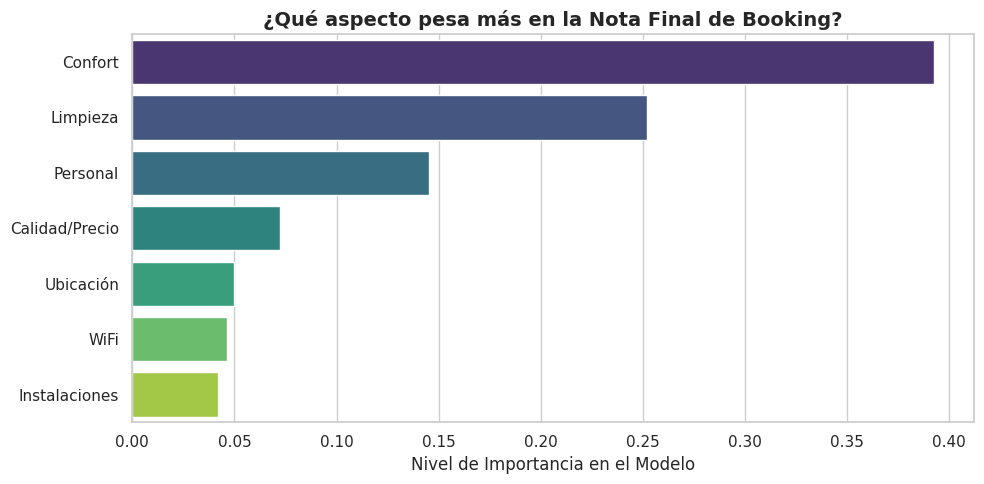

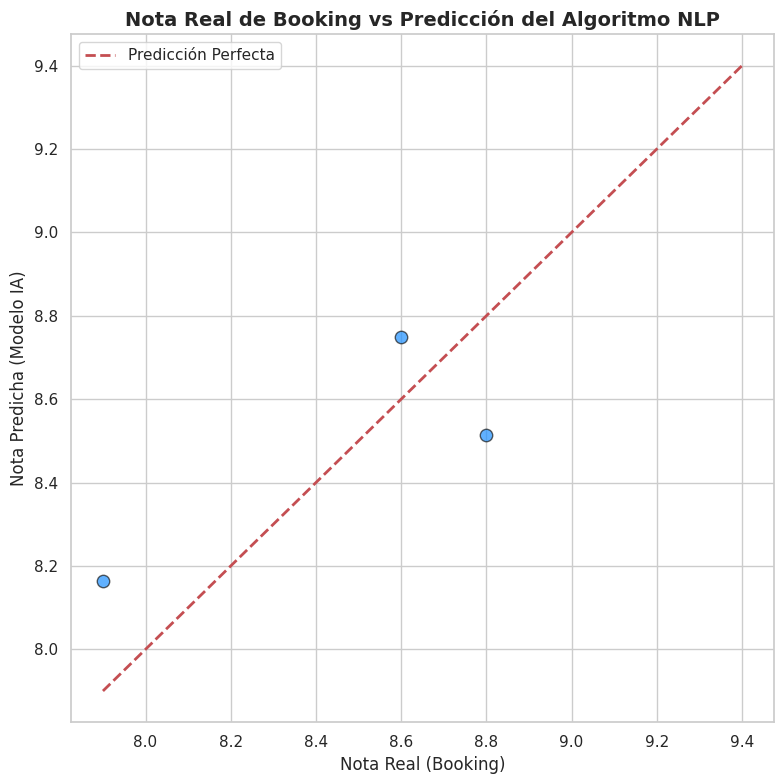

In [16]:

# ------------------------------------------------------------------------------
# FASE 4: MACHINE LEARNING (PREDICCIÓN)
# ------------------------------------------------------------------------------
print("🤖 Entrenando el modelo de predicción (Random Forest)...")

# Variables predictoras (Los índices de los tópicos)
X = df_final[cols_indices]
# Variable a predecir (La nota media real)
y = df_final['nota_media_resenas']

# Dividimos en conjunto de entrenamiento (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializamos y entrenamos el modelo
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Hacemos las predicciones con los datos que el modelo no ha visto
y_pred = modelo_rf.predict(X_test)

# ------------------------------------------------------------------------------
# FASE 5: EVALUACIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("📊 RESULTADOS DEL MODELO")
print("="*50)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Error Absoluto Medio (MAE): {mae:.2f} puntos (La predicción falla por {mae:.2f} puntos sobre 10)")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Precisión del Modelo (R2 Score): {r2:.2f} (1.0 es perfecto)\n")

# --- GRÁFICO 1: Importancia de los Tópicos ---
importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Tópico': categorias, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Tópico', data=df_importancias, palette='viridis')
plt.title('¿Qué aspecto pesa más en la Nota Final de Booking?', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Importancia en el Modelo')
plt.ylabel('')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: Nota Real vs Nota Predicha ---
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.7, color='dodgerblue', edgecolors='k', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Predicción Perfecta')
plt.title('Nota Real de Booking vs Predicción del Algoritmo NLP', fontsize=14, fontweight='bold')
plt.xlabel('Nota Real (Booking)')
plt.ylabel('Nota Predicha (Modelo IA)')
plt.legend()
plt.tight_layout()
plt.show()

### Segunda parte

⏳ Cargando datos...
🧠 Calculando índices de sentimiento textuales ponderados...
📊 Generando análisis de correlación...


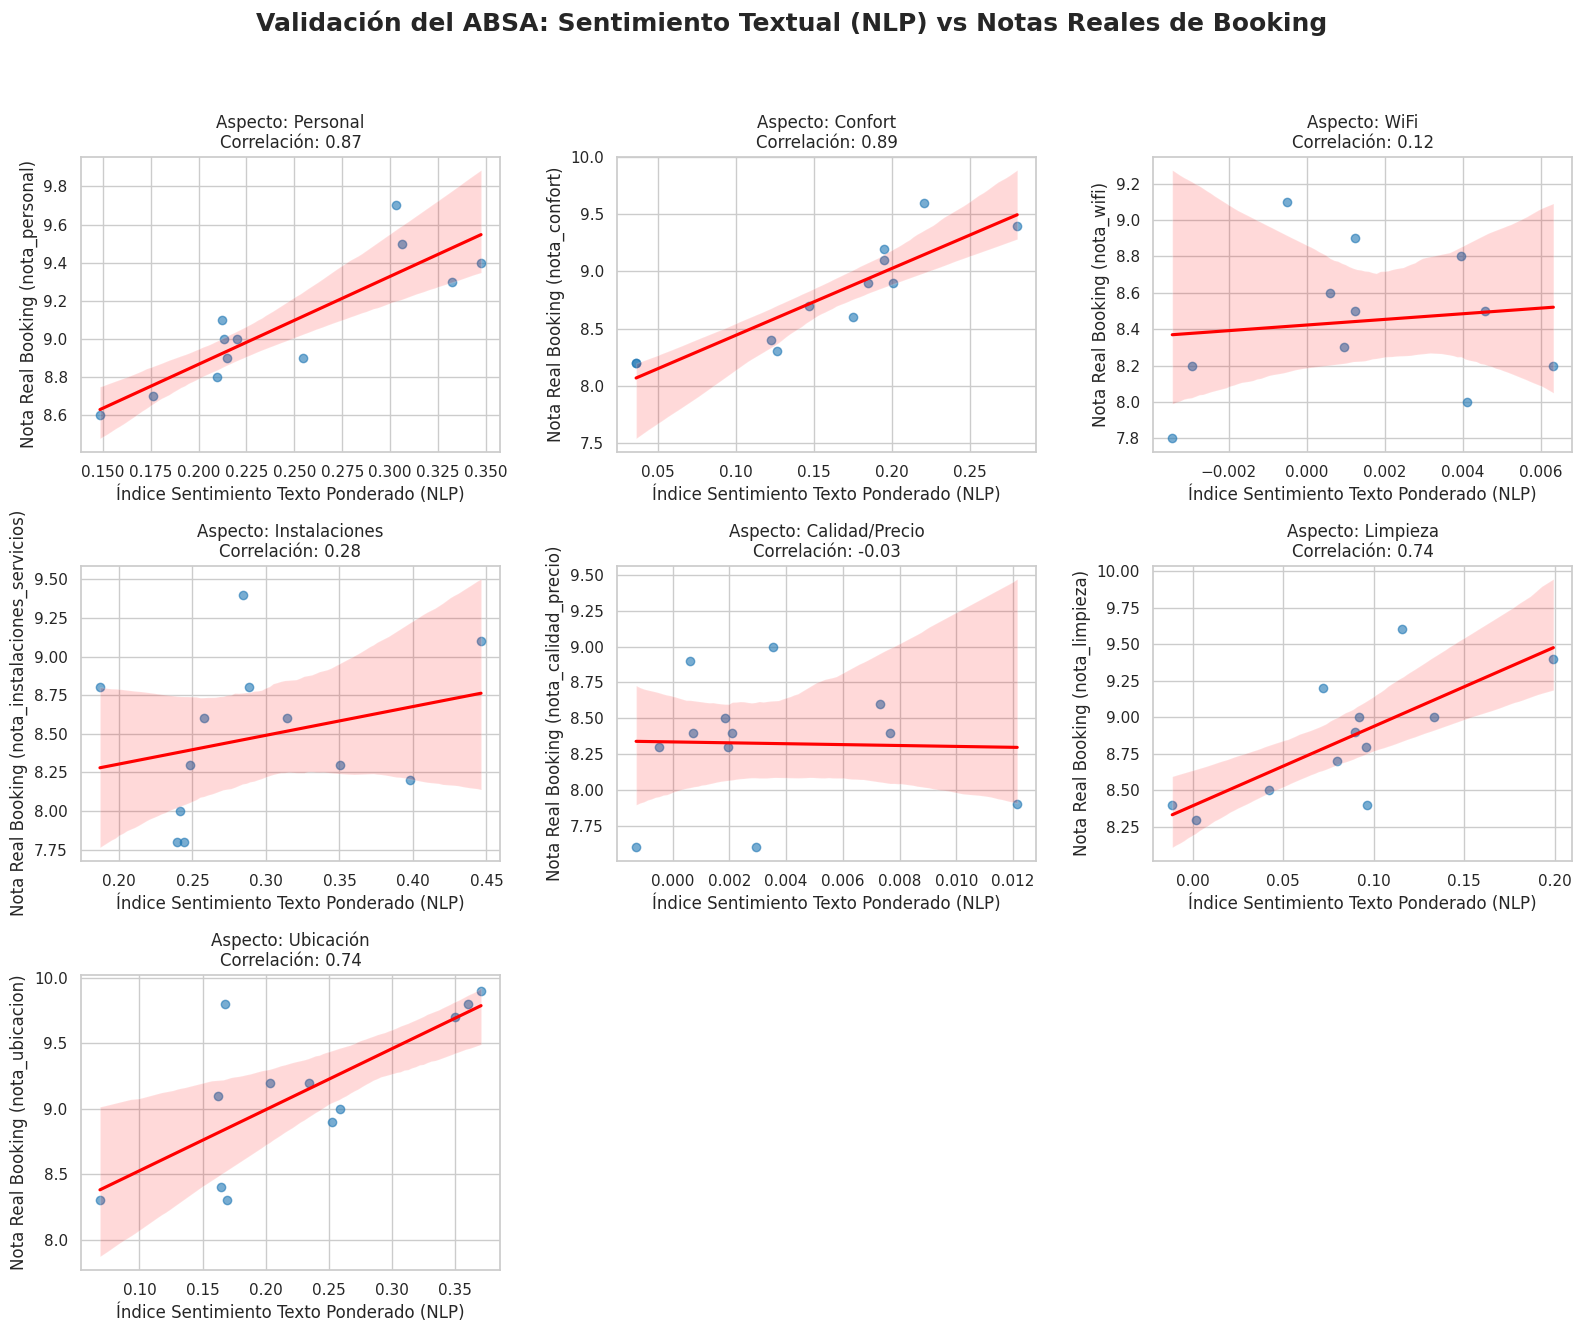


🏆 RANKING DE FIABILIDAD DEL MODELO NLP


,Aspecto,Correlacion
1,Confort,0.888284
0,Personal,0.868888
6,Ubicación,0.738943
5,Limpieza,0.736292
3,Instalaciones,0.276044
2,WiFi,0.121172
4,Calidad/Precio,-0.027756


In [18]:
# ==============================================================================
# OBJETIVO 2: ABSA Y VALIDACIÓN DE NOTAS POR ASPECTO (CON PESO TEMPORAL)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Configuración visual
sns.set_theme(style="whitegrid")

print("⏳ Cargando datos...")
df_info = pd.read_csv('df_hoteles_vlc_info.csv')
df_comentarios = pd.read_csv('df_comentarios_final_topics.csv')


df_comentarios['fecha'] = pd.to_datetime(df_comentarios['fecha'], dayfirst=False, errors='coerce')
df_comentarios = df_comentarios.dropna(subset=['fecha', 'nota'])

HALF_LIFE_DIAS = 180
fecha_ref = df_comentarios['fecha'].max()
df_comentarios['dias_antiguedad'] = (fecha_ref - df_comentarios['fecha']).dt.days
df_comentarios['peso_temporal']   = np.power(2, -df_comentarios['dias_antiguedad'] / HALF_LIFE_DIAS)

# ------------------------------------------------------------------------------
# FASE 1: FEATURE ENGINEERING (Índices NLP Ponderados por Fecha)
# ------------------------------------------------------------------------------
print("🧠 Calculando índices de sentimiento textuales ponderados...")

# Diccionario para mapear tu Tópico NLP con la columna de nota real en tu CSV
mapa_aspectos = {
    'Personal': 'nota_personal',
    'Confort': 'nota_confort',
    'WiFi': 'nota_wifi',
    'Instalaciones': 'nota_instalaciones_servicios',
    'Calidad/Precio': 'nota_calidad_precio',
    'Limpieza': 'nota_limpieza',
    'Ubicación': 'nota_ubicacion'
}

# 1. Calculamos índices base y su versión ponderada
for cat in mapa_aspectos.keys():
    df_comentarios[f'{cat}_pos'] = df_comentarios['tema_positivo'].str.contains(cat, na=False, case=False).astype(int)
    df_comentarios[f'{cat}_neg'] = df_comentarios['tema_negativo'].str.contains(cat, na=False, case=False).astype(int)

    # Índice base de -1 a 1
    df_comentarios[f'indice_nlp_{cat}'] = df_comentarios[f'{cat}_pos'] - df_comentarios[f'{cat}_neg']

    # Índice ponderado (Multiplicamos por la relevancia de la fecha)
    df_comentarios[f'indice_pond_{cat}'] = df_comentarios[f'indice_nlp_{cat}'] * df_comentarios['peso_temporal']

# 2. Agrupamos por hotel calculando la SUMA de índices ponderados y de pesos
cols_ponderadas = [f'indice_pond_{cat}' for cat in mapa_aspectos.keys()]
df_agrupado = df_comentarios.groupby('nombre_del_hotel')[cols_ponderadas + ['peso_temporal']].sum().reset_index()

# 3. Calculamos la media ponderada final dividiendo por la suma de pesos del hotel
for cat in mapa_aspectos.keys():
    df_agrupado[f'indice_nlp_{cat}'] = df_agrupado[f'indice_pond_{cat}'] / df_agrupado['peso_temporal']

# 4. Limpiamos el dataframe para dejar solo las columnas que necesita la FASE 2
cols_finales = ['nombre_del_hotel'] + [f'indice_nlp_{cat}' for cat in mapa_aspectos.keys()]
df_agrupado = df_agrupado[cols_finales]

# ------------------------------------------------------------------------------
# FASE 2: MERGE CON LAS NOTAS REALES DE CADA ASPECTO
# ------------------------------------------------------------------------------
df_agrupado['nombre_del_hotel_lower'] = df_agrupado['nombre_del_hotel'].str.lower()
df_info['nombre_del_hotel_lower'] = df_info['nombre_del_hotel'].str.lower()

# Unimos
df_final = pd.merge(df_info, df_agrupado, on='nombre_del_hotel_lower', how='inner')

# ------------------------------------------------------------------------------
# FASE 3: ANÁLISIS DE CORRELACIÓN Y VISUALIZACIÓN
# ------------------------------------------------------------------------------
print("📊 Generando análisis de correlación...")

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('Validación del ABSA: Sentimiento Textual (NLP) vs Notas Reales de Booking', fontsize=18, fontweight='bold')
axes = axes.flatten()

correlaciones = []

for i, (topico_nlp, col_nota_real) in enumerate(mapa_aspectos.items()):
    # Filtramos nulos para ese aspecto concreto
    df_plot = df_final.dropna(subset=[f'indice_nlp_{topico_nlp}', col_nota_real])

    x = df_plot[f'indice_nlp_{topico_nlp}']
    y = df_plot[col_nota_real]

    # Calcular correlación de Pearson
    if len(x) > 2:
        corr, p_value = pearsonr(x, y)
        correlaciones.append({'Aspecto': topico_nlp, 'Correlacion': corr})
    else:
        corr = 0

    # Gráfico de dispersión con línea de tendencia
    sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={'alpha':0.6, 'color':'#1f77b4'}, line_kws={'color':'red'})
    axes[i].set_title(f'Aspecto: {topico_nlp}\nCorrelación: {corr:.2f}', fontsize=12)
    axes[i].set_xlabel('Índice Sentimiento Texto Ponderado (NLP)')
    axes[i].set_ylabel(f'Nota Real Booking ({col_nota_real})')

# Eliminamos los gráficos sobrantes vacíos (7 aspectos = 2 gráficos vacíos en la grid 3x3)
fig.delaxes(axes[7])
fig.delaxes(axes[8])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- TABLA RESUMEN DE CORRELACIÓN ---
print("\n🏆 RANKING DE FIABILIDAD DEL MODELO NLP")
df_corr = pd.DataFrame(correlaciones).sort_values(by='Correlacion', ascending=False)
display(df_corr)